In [1]:
import sys
print(sys.executable)

c:\Users\sandr\anaconda3\python.exe


In [2]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\sandr\OneDrive\Dokumenty\co2-time-series-forecasting\notebooks
['neural_network.ipynb']


In [ ]:
import numpy as np
import pandas as pd

cols = [
    "year", "month", "decimal_date", "average",
    "interpolated", "trend", "days", "stdv"
]

df = pd.read_csv("../data/co2_mm_mlo.txt", comment="#", sep=r"\s+", header=None, names=cols)

# jeśli monthly average jest brakujący, bierzemy interpolated
df["co2"] = np.where(df["average"] > 0, df["average"], df["interpolated"])

# tworzymy normalną datę
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))

# zostawiamy tylko potrzebne kolumny
df = df[["date", "co2"]].copy()

print(df.head())
print(df.tail())
print("\nShape:", df.shape)

        date     co2
0 1958-03-01  315.71
1 1958-04-01  317.45
2 1958-05-01  317.51
3 1958-06-01  317.27
4 1958-07-01  315.87
          date     co2
811 2025-10-01  424.87
812 2025-11-01  426.46
813 2025-12-01  427.49
814 2026-01-01  428.62
815 2026-02-01  429.35

Shape: (816, 2)


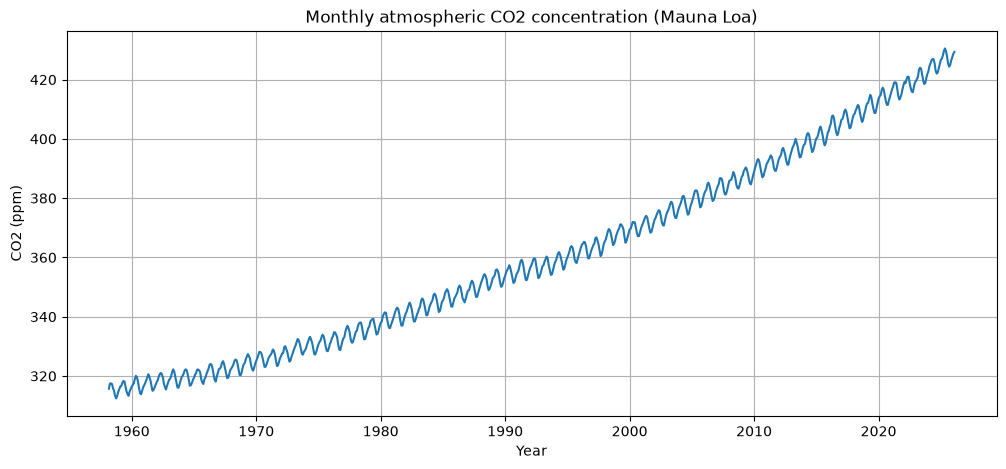

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["co2"])
plt.title("Monthly atmospheric CO2 concentration (Mauna Loa)")
plt.xlabel("Year")
plt.ylabel("CO2 (ppm)")
plt.grid()

plt.show()

In [66]:
y = df["co2"].to_numpy(dtype=float)

# skalowanie (jak u Chatfielda)
y = y / 100.0

print(y[:5])

[3.1571 3.1745 3.1751 3.1727 3.1587]


In [ ]:
# Final test period: March 2025 - February 2026
test_size = 12

# Validation period: March 2024 - February 2025
val_size = 12

# Chronological split
train_end = len(y) - val_size - test_size
val_end = len(y) - test_size

train = y[:train_end]
validation = y[train_end:val_end]
test = y[val_end:]

print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

print("\nTrain period:")
print(df["date"].iloc[0], "to", df["date"].iloc[train_end - 1])

print("\nValidation period:")
print(df["date"].iloc[train_end], "to", df["date"].iloc[val_end - 1])

print("\nTest period:")
print(df["date"].iloc[val_end], "to", df["date"].iloc[-1])

Train: 792
Validation: 12
Test: 12

Train period:
1958-03-01 00:00:00 to 2024-02-01 00:00:00

Validation period:
2024-03-01 00:00:00 to 2025-02-01 00:00:00

Test period:
2025-03-01 00:00:00 to 2026-02-01 00:00:00


In [71]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

def make_lagged_xy(series, lags):
    X, target = [], []
    max_lag = max(lags)
    for t in range(max_lag, len(series)):
        X.append([series[t - lag] for lag in lags])
        target.append(series[t])
    return np.array(X), np.array(target)

def predict_one(x, model, x_scaler, y_scaler):
    x_scaled = x_scaler.transform(x.reshape(1, -1))
    y_pred_scaled = model.predict(x_scaled).reshape(-1, 1)
    y_pred = y_scaler.inverse_transform(y_pred_scaled).ravel()[0]
    return y_pred

def recursive_forecast(train, test, lags, hidden_units=2, random_state=0):
    X_train, y_train = make_lagged_xy(train, lags)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaled = x_scaler.fit_transform(X_train)
    y_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

    model = MLPRegressor(
        hidden_layer_sizes=(hidden_units,),
        activation="logistic",
        solver="lbfgs",
        max_iter=1000,
        random_state=random_state
    )
    model.fit(X_scaled, y_scaled)

    history = list(train)
    preds = []

    for i in range(len(test)):
        x = np.array([history[-lag] for lag in lags])
        y_hat = predict_one(x, model, x_scaler, y_scaler)
        preds.append(y_hat)
        history.append(y_hat)

    preds = np.array(preds)

    test_ppm = test * 100
    preds_ppm = preds * 100

    rmse = np.sqrt(np.mean((test_ppm - preds_ppm) ** 2))
    mae = np.mean(np.abs(test_ppm - preds_ppm))
    mape = np.mean(np.abs((test_ppm - preds_ppm) / test_ppm)) * 100

    return rmse, mae, mape

candidates = [
    ([1, 12], 2),
    ([1, 12, 13], 1),
    ([1, 12, 13], 2),
    ([1, 2, 12, 13], 2),
]

validation_results = []

for lags, hidden in candidates:
    rmse, mae, mape = recursive_forecast(
        train,
        validation,
        lags,
        hidden_units=hidden,
        random_state=0
    )

    validation_results.append({
    "Model": f"NN({','.join(map(str, lags))};{hidden})",
    "Validation RMSE": rmse,
    "Validation MAE": mae,
    "Validation MAPE": mape
    })

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

validation_results_df

,Model,Validation RMSE,Validation MAE,Validation MAPE
0,"NN(1,12;2)",0.770648,0.669242,0.157500
1,"NN(1,12,13;1)",1.203445,1.099818,0.258820
2,"NN(1,2,12,13;2)",1.855567,1.635063,0.385109
3,"NN(1,12,13;2)",3.293772,3.134701,0.737574


In [ ]:
# NN(1,12;2) achieved the lowest validation RMSE
selected_lags = [1, 12]
selected_hidden = 2

print("Selected architecture: NN(1,12;2)")

# Refit the selected architecture on all pre-test data
final_train = np.concatenate([train, validation])

print("Final training observations:", len(final_train))
print("Final training period:",
      df["date"].iloc[0],
      "to",
      df["date"].iloc[len(final_train) - 1])

print("Final test period:",
      df["date"].iloc[len(final_train)],
      "to",
      df["date"].iloc[-1])

Selected architecture: NN(1,12;2)
Final training observations: 804
Final training period: 1958-03-01 00:00:00 to 2025-02-01 00:00:00
Final test period: 2025-03-01 00:00:00 to 2026-02-01 00:00:00


In [ ]:
final_rmse, final_mae, final_mape = recursive_forecast(
    final_train,
    test,
    selected_lags,
    hidden_units=selected_hidden,
    random_state=0
)

print("Selected model: NN(1,12;2)")
print("Final TEST RMSE:", final_rmse)
print("Final TEST MAE:", final_mae)
print("Final TEST MAPE:", final_mape)

Selected model: NN(1,12;2)
Final TEST RMSE: 0.7941557798361005
Final TEST MAE: 0.7051868645504413
Final TEST MAPE: 0.1650181875774157


In [ ]:
def recursive_forecast_values(train, test, lags, hidden_units=2, random_state=0):
    X_train, y_train = make_lagged_xy(train, lags)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaled = x_scaler.fit_transform(X_train)
    y_scaled = y_scaler.fit_transform(
        y_train.reshape(-1, 1)
    ).ravel()

    model = MLPRegressor(
        hidden_layer_sizes=(hidden_units,),
        activation="logistic",
        solver="lbfgs",
        max_iter=1000,
        random_state=random_state
    )

    model.fit(X_scaled, y_scaled)

    history = list(train)
    preds = []

    for i in range(len(test)):
        x = np.array([history[-lag] for lag in lags])

        y_hat = predict_one(
            x,
            model,
            x_scaler,
            y_scaler
        )

        preds.append(y_hat)
        history.append(y_hat)

    return np.array(preds)

In [ ]:
final_preds = recursive_forecast_values(
    final_train,
    test,
    [1, 12],
    hidden_units=2,
    random_state=0
)

final_preds_ppm = final_preds * 100
test_ppm = test * 100

print("Actual:")
print(test_ppm)

print("\nFinal NN forecast:")
print(final_preds_ppm)

Actual:
[428.15 429.64 430.51 429.61 427.87 425.48 424.37 424.87 426.46 427.49
 428.62 429.35]

Final NN forecast:
[428.39792772 429.5940224  430.12071812 430.21011569 429.02773052
 426.59650533 425.37637051 425.49350122 426.80415267 428.37135544
 429.71317303 430.30615076]


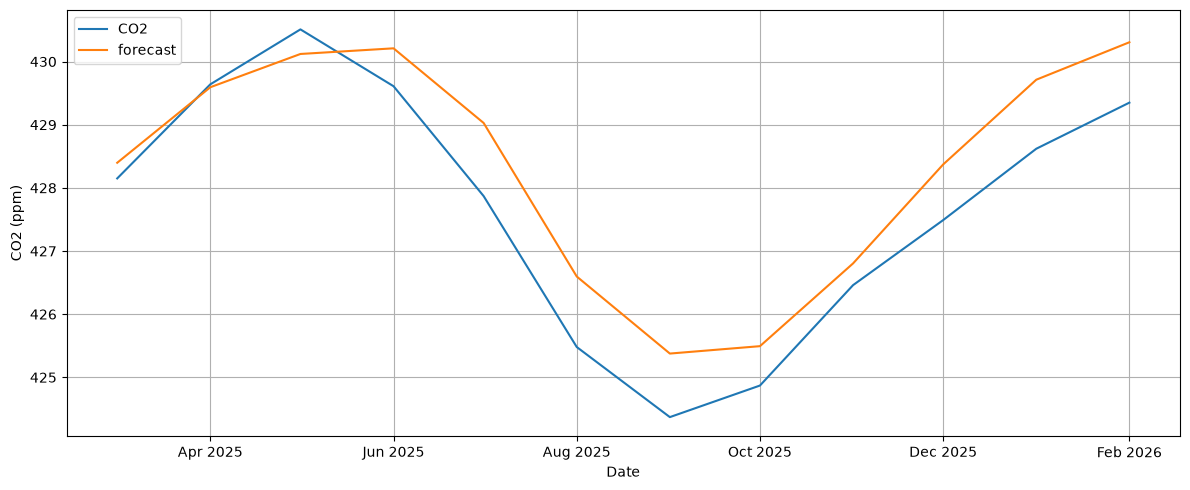

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Dates of the untouched final test period
test_dates = df["date"].iloc[-12:]

plt.figure(figsize=(12, 5))

plt.plot(test_dates, test_ppm, label="CO2")
plt.plot(test_dates, final_preds_ppm, label="forecast")

plt.xlabel("Date")
plt.ylabel("CO2 (ppm)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()